In [2]:
from pathlib import Path
import sys

cwd = Path.cwd().resolve()
repo_root = cwd if (cwd / "src").exists() else cwd.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from src.utils import bootstrap_project_paths

project_root = bootstrap_project_paths()

from src.data import load_sales
from src.pipelines import train_validate_models
from src.features import one_hot_encode, add_lag_features, add_rolling_features
from src.models import *
import pandas as pd
import numpy as np

DATA_ROOT= project_root / "data/datathon-2026-round-1"

d:\MyML\datathon2026\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Project root: D:\MyML\datathon2026
Source path added: D:\MyML\datathon2026\src


In [3]:
TRAIN_RANGE = ("2013-01-01","2021-12-31")  # Date range for training data
VALIDATION_RANGE = ("2022-01-01","2022-12-31")  # Date range for validation data

df = load_sales(data_root=DATA_ROOT)
# Basic time features
df["day"] = df["date"].dt.day
df["month"] = df["date"].dt.month
#df["year"] = df["date"].dt.year
year = df["date"].dt.year

# day_of_month, isweekend không không thay dổi performance 
# nhưng không thể thay thế 2 feature trên
df["day_of_week"] = df["date"].dt.dayofweek
df["week_of_year"] = df["date"].dt.isocalendar().week


# Cái này quan trọng
df["month_sin"] = np.sin(2 * np.pi * df["month"]/12)
df["month_cos"] = np.cos(2 * np.pi * df["month"]/12)

# Cái feature này thần kỳ vcl
df["is_month8_odd"] = ((df["month"] == 8) & (year % 2 == 1))

# Cần giải thích tại sao lag 30 cho revenue lại tệ
# 11 mạnh vượt trội, 12, 13, 14 cải thiện nhưng không lấy 
# 21, 28, 30, 10 làm tệ đi
# df = add_lag_features(df, lags=[1,7,11], target_col="Revenue", date_col="date")

df = add_lag_features(df, lags=[1,7], target_col="COGS", date_col="date")

# Cần giải thích tại sao rolling 7, 30 cho revenue lại tệ
# df = add_rolling_features(df, windows=[7, 30], target_col="Revenue", date_col="date")

# phải đi chung 3 thằng nó mới tốt

df["is_peak_period"] = ((df["day"] <= 5) | (df["day"] >= 25)).astype(int)
df["is_peak_period_lag7"] = df["is_peak_period"].shift(7)
df["is_peak_period_lag1"] = df["is_peak_period"].shift(1)

model_config = SklearnRegressorConfig(
    model_type="lightgbm"
)
results = train_validate_models(
    df,
    train_range=TRAIN_RANGE,
    predict_range=VALIDATION_RANGE,
    model_config=model_config,
    #importance_plot= True
)
results["metrics"]

{'Revenue': {'mae': 555457.2119385265,
  'rmse': 767653.5779495826,
  'mape': 21.676567494731717,
  'smape': 19.20826349730975,
  'r2': 0.7896617351415406},
 'COGS': {'mae': 479809.10779676586,
  'rmse': 655760.5017187281,
  'mape': 20.969247273976976,
  'smape': 18.906199360315977,
  'r2': 0.797866864248536}}

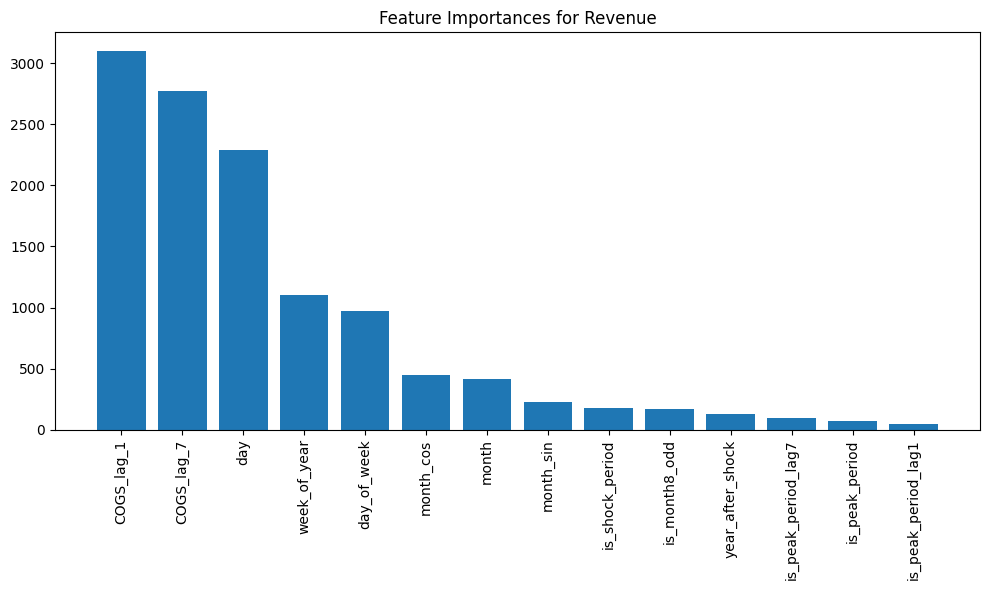

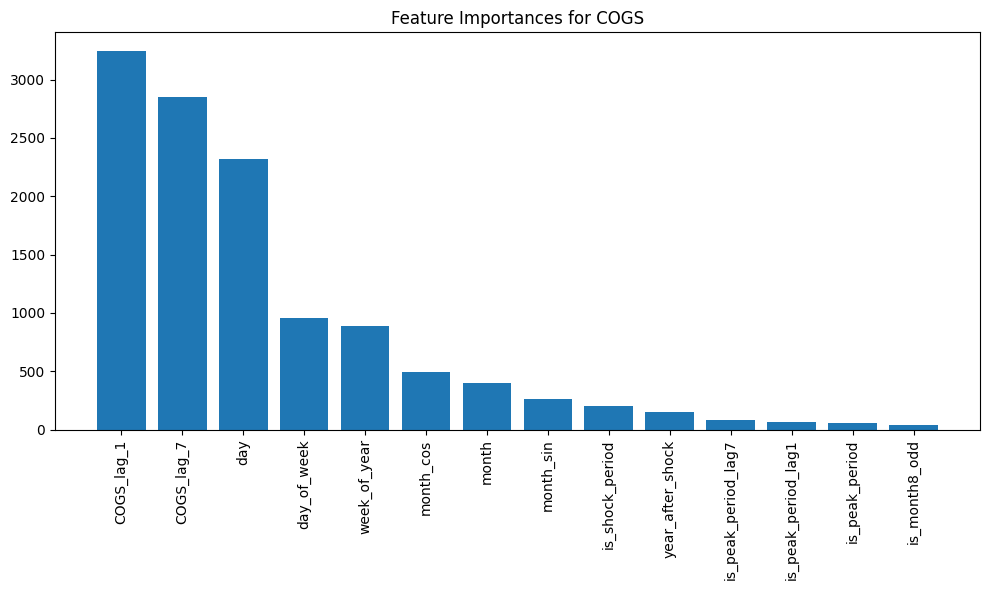

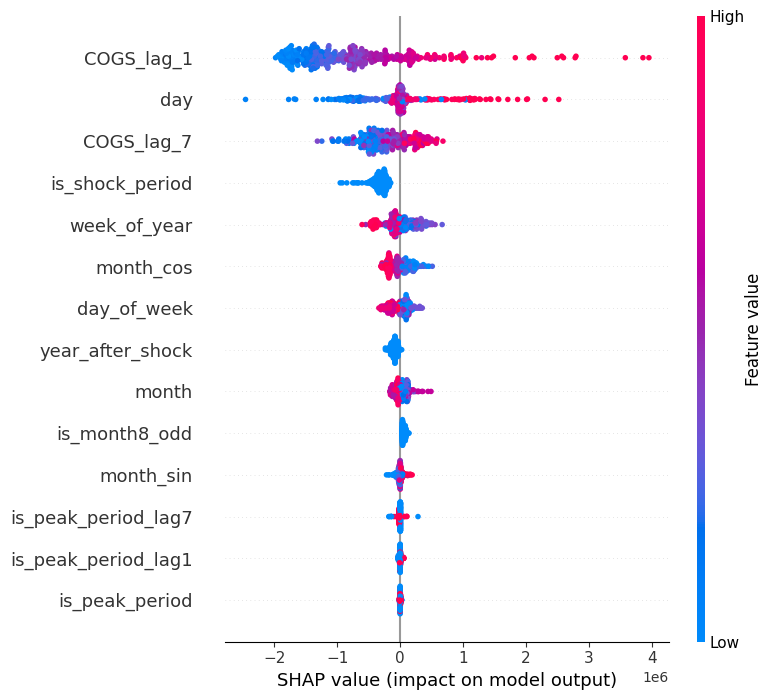

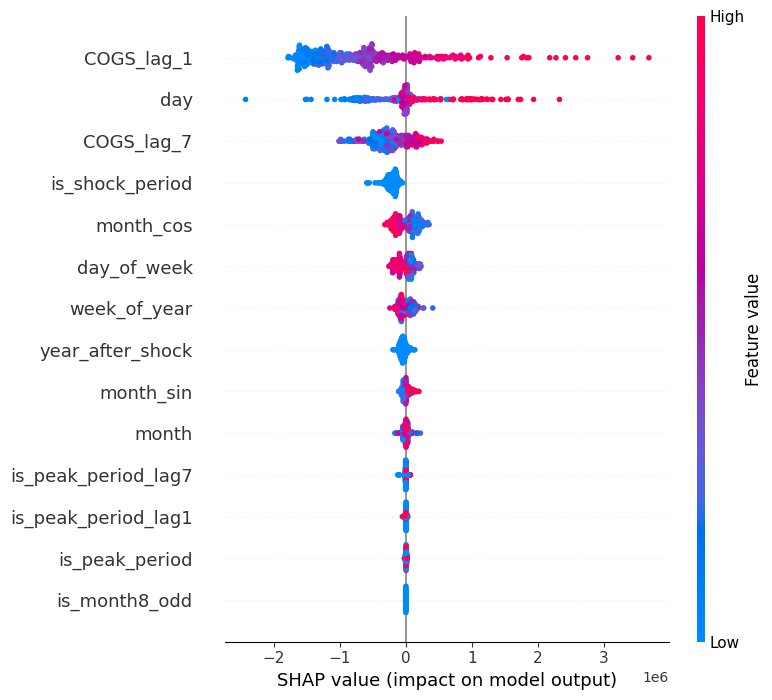

{'Revenue': {'mae': 534209.0886253882,
  'rmse': 736275.8244559793,
  'mape': 19.039466367495315,
  'smape': 18.23045679562888,
  'r2': 0.8065054168837968},
 'COGS': {'mae': 469246.6507881245,
  'rmse': 647955.7937934399,
  'mape': 19.327408648772774,
  'smape': 18.523395734772492,
  'r2': 0.802649714171847}}

In [4]:
df["is_shock_period"] = (year >= 2019).astype(int)
df["year_after_shock"] = (year - 2019).clip(lower=0)

model_config = SklearnRegressorConfig(
    model_type="lightgbm"
)
results = train_validate_models(
    df,
    train_range=TRAIN_RANGE,
    predict_range=VALIDATION_RANGE,
    model_config=model_config,
    importance_plot= True,
    shap_plot= True
)
results["metrics"]

# Dựa trên plot feature importance và shap plot
# Có thể thấy is_peak_period và lag có ảnh hưởng lớn đến metrics
# SHAP và importance đều cho thấy ảnh hưởng thấp do đây là sự kiện hiếm
# Việc RMSE giảm mạnh trong khi MAE tăng cho thấy feature này giải thích
# tốt các outlier

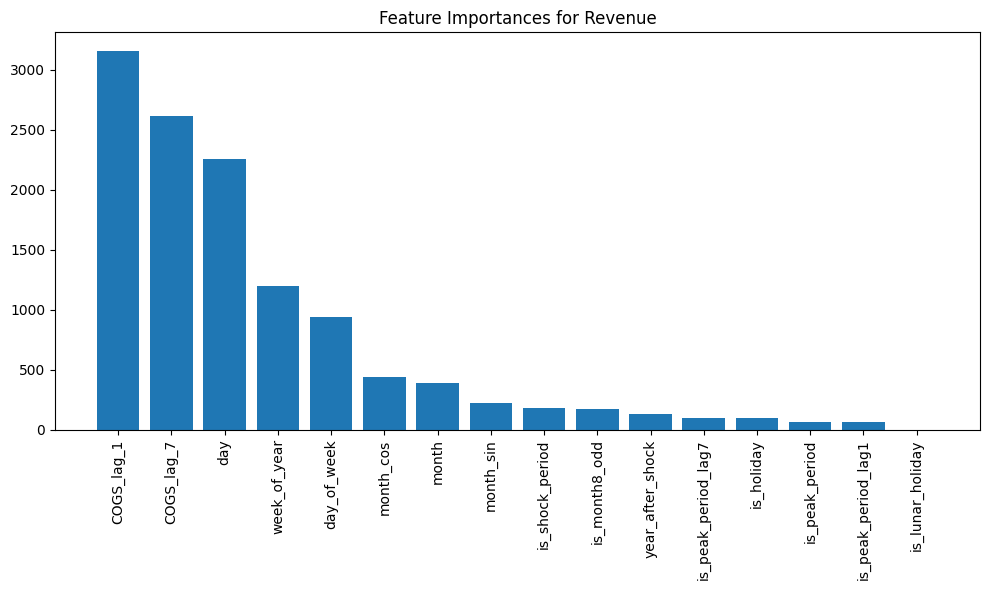

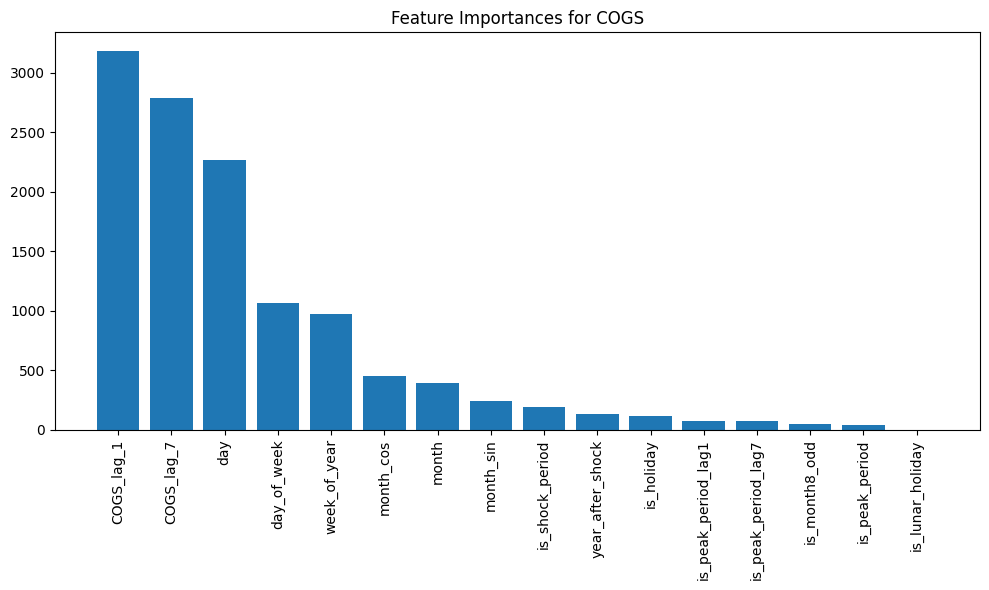

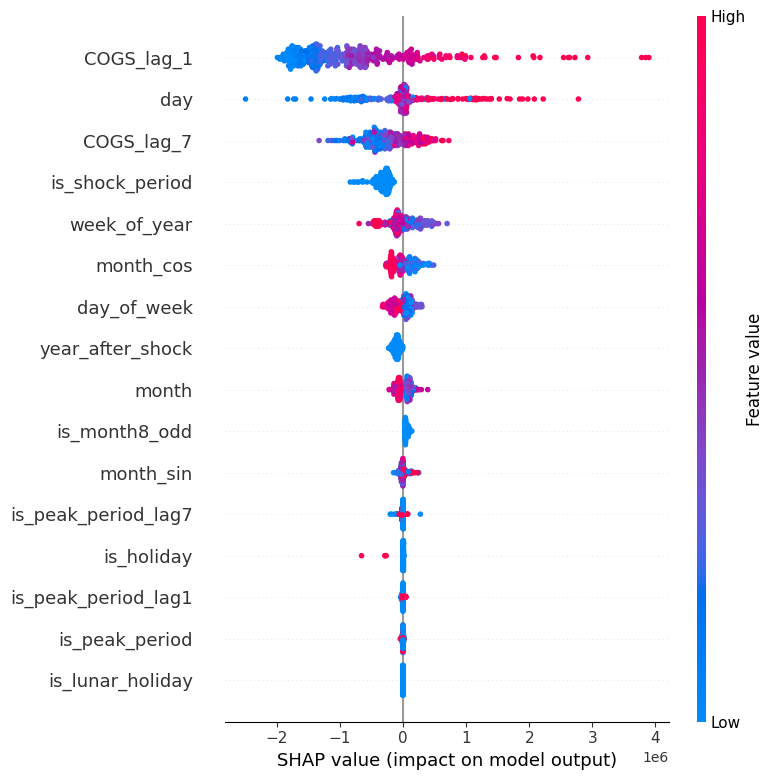

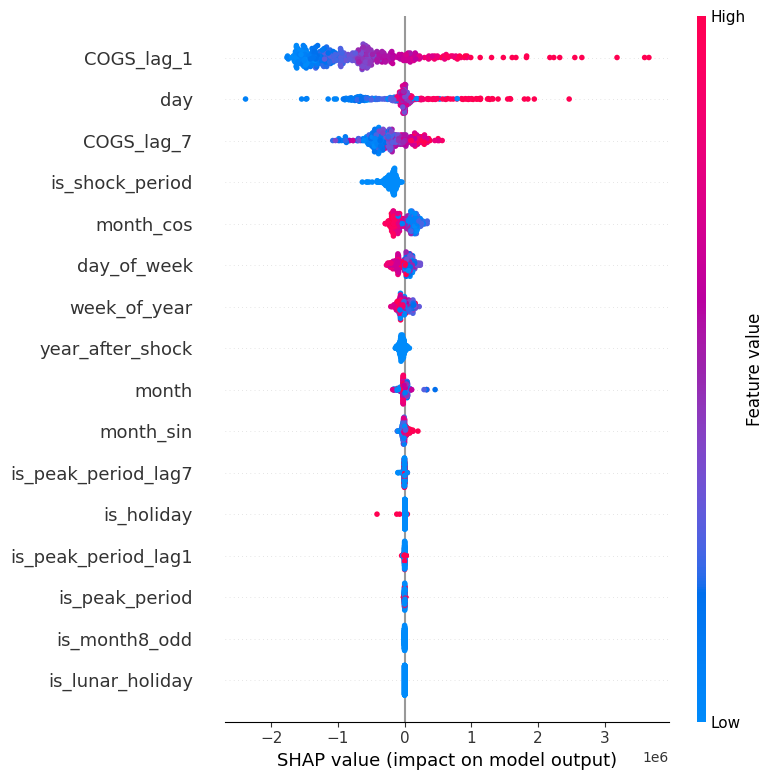

In [ ]:
# Holiday features
fixed_holidays = [
    {"day": 1, "month": 1, "name": "New Year's Day"},
    {"day": 30, "month": 4, "name": "Victory Day"},
    {"day": 1, "month": 5, "name": "International Labor Day"},
    {"day": 2, "month": 9, "name": "National Day"},
]

years = df["date"].dt.year.dropna().unique().tolist()
fixed_dates = []
for y in years:
    for h in fixed_holidays:
        fixed_dates.append(pd.Timestamp(year=int(y), month=h["month"], day=h["day"]))
fixed_dates = pd.to_datetime(fixed_dates)
holiday_dates = pd.to_datetime(pd.Index(fixed_dates))

df["is_holiday"] = df["date"].isin(holiday_dates).astype(int)

model_config = SklearnRegressorConfig(
    model_type="lightgbm"
)
results = train_validate_models(
    df,
    train_range=TRAIN_RANGE,
    predict_range=VALIDATION_RANGE,
    model_config=model_config,
    importance_plot= True,
    shap_plot= True
)

In [6]:
results["metrics"]

{'Revenue': {'mae': 533366.3967380418,
  'rmse': 732160.4622012782,
  'mape': 19.152515417167177,
  'smape': 18.32802420649733,
  'r2': 0.8086624206723947},
 'COGS': {'mae': 472142.88486355235,
  'rmse': 651026.9071346277,
  'mape': 19.403108994147207,
  'smape': 18.584743868553105,
  'r2': 0.8007745201200356}}